# Домашнее задание 3: Алгоритмы выравнивания
**МФТИ, ФБМФ**

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

---
## Задание 3. Аффинные штрафы за гэпы (1 балл)

Строки: **S1 = ATGCAGCAGCAGCCA**, **S2 = ATATAT**  
- Линейный штраф: Gap = −4  
- Аффинный штраф: Open = −10, Extend = −1

In [8]:
NEG_INF = -10**9


def nw_linear(x, y, match=3, mismatch=-3, gap=-4):
    m, n = len(y), len(x)
    H = np.full((m + 1, n + 1), NEG_INF, dtype=float)
    H[0][0] = 0
    for i in range(1, m + 1):
        H[i][0] = i * gap
    for j in range(1, n + 1):
        H[0][j] = j * gap
    for i in range(1, m + 1):
        for j in range(1, n + 1):
            s = match if y[i-1] == x[j-1] else mismatch
            H[i][j] = max(
                H[i-1][j-1] + s,
                H[i-1][j] + gap,
                H[i][j-1] + gap
            )
    score = H[m][n]
    align_x, align_y = [], []
    i, j = m, n
    while i > 0 or j > 0:
        s = match if (i > 0 and j > 0 and y[i-1] == x[j-1]) else mismatch
        if i > 0 and j > 0 and H[i][j] == H[i-1][j-1] + s:
            align_x.append(x[j-1]); align_y.append(y[i-1])
            i -= 1; j -= 1
        elif i > 0 and H[i][j] == H[i-1][j] + gap:
            align_x.append('-'); align_y.append(y[i-1])
            i -= 1
        else:
            align_x.append(x[j-1]); align_y.append('-')
            j -= 1
    return int(score), ''.join(reversed(align_x)), ''.join(reversed(align_y)), H


def nw_affine(x, y, match=3, mismatch=-3, gap_open=-10, gap_extend=-1):
    """
    Нидлман-Вунш с аффинными штрафами за гэп.
    Стоимость гэпа длиной k: gap_open + k * gap_extend.
    Используем три матрицы:
      M[i][j] — заканчивается совпадением/заменой
      E[i][j] — заканчивается гэпом в X (пропуск в x)
      F[i][j] — заканчивается гэпом в Y (пропуск в y)
    """
    m, n = len(y), len(x)
    M = np.full((m + 1, n + 1), NEG_INF, dtype=float)
    E = np.full((m + 1, n + 1), NEG_INF, dtype=float)
    F = np.full((m + 1, n + 1), NEG_INF, dtype=float)
    M[0][0] = 0
    for i in range(1, m + 1):
        E[i][0] = gap_open + i * gap_extend
        M[i][0] = E[i][0]
    for j in range(1, n + 1):
        F[0][j] = gap_open + j * gap_extend
        M[0][j] = F[0][j]
    for i in range(1, m + 1):
        for j in range(1, n + 1):
            s = match if y[i-1] == x[j-1] else mismatch
            E[i][j] = max(M[i-1][j] + gap_open + gap_extend,
                          E[i-1][j] + gap_extend)
            F[i][j] = max(M[i][j-1] + gap_open + gap_extend,
                          F[i][j-1] + gap_extend)
            M[i][j] = max(M[i-1][j-1] + s, E[i][j], F[i][j])
    score = M[m][n]
    # трейсбэк
    align_x, align_y = [], []
    i, j = m, n
    state = 'M'
    while i > 0 or j > 0:
        if state == 'M':
            s = match if y[i-1] == x[j-1] else mismatch
            if M[i][j] == E[i][j]:
                state = 'E'
            elif M[i][j] == F[i][j]:
                state = 'F'
            else:
                align_x.append(x[j-1]); align_y.append(y[i-1])
                i -= 1; j -= 1
        elif state == 'E':
            align_x.append('-'); align_y.append(y[i-1])
            if E[i][j] == M[i-1][j] + gap_open + gap_extend:
                state = 'M'
            i -= 1
        else:  # F
            align_x.append(x[j-1]); align_y.append('-')
            if F[i][j] == M[i][j-1] + gap_open + gap_extend:
                state = 'M'
            j -= 1
    return int(score), ''.join(reversed(align_x)), ''.join(reversed(align_y)), M


S1 = "ATGCAGCAGCAGCCA"
S2 = "ATATAT"

score_lin, ax_lin, ay_lin, H_lin = nw_linear(S1, S2)
score_aff, ax_aff, ay_aff, H_aff = nw_affine(S1, S2)

print("Линейный штраф (Gap = −4)")
print(f"Score = {score_lin}")
print(f"  S1: {ax_lin}")
mid = ''.join('|' if a==b else ' ' for a,b in zip(ax_lin, ay_lin))
print(f"      {mid}")
print(f"  S2: {ay_lin}")

print()
print("Аффинный штраф (Open = −10, Extend = −1)")
print(f"Score = {score_aff}")
print(f"  S1: {ax_aff}")
mid = ''.join('|' if a==b else ' ' for a,b in zip(ax_aff, ay_aff))
print(f"      {mid}")
print(f"  S2: {ay_aff}")

Линейный штраф (Gap = −4)
Score = -30
  S1: ATGCAGCAGCAGCCA
      ||     |  |    
  S2: AT-----A-TA---T

Аффинный штраф (Open = −10, Extend = −1)
Score = -19
  S1: ATGCAGCAGCAGCCA
      ||  |          
  S2: ATATAT---------


### Биологический смысл аффинной модели

Аффинная модель штрафов за гэпы лучше описывает **биологические инделы** (вставки и делеции). Реальные мутации чаще всего происходят как **единичные события** — полимераза «проскальзывает» на несколько нуклеотидов за раз, создавая один протяжённый гэп. Поэтому:

- Открытие гэпа (Open = −10) штрафуется тяжело — это редкое событие;
- Продолжение гэпа (Extend = −1) штрафуется слабо — это лишь продолжение уже начавшегося события.

Для гэпа длиной k:
- линейный штраф = k × (−4)
- аффинный штраф = −10 + k × (−1) = −(10 + k)

При k ≥ 4 аффинный штраф выгоднее линейного → модель **предпочитает один длинный гэп** нескольким коротким, что биологически оправдано.

---
## Задание 4. Seed-and-Extend (1 балл)

- Референс: **CTAGGATCCAGGCATACGA**  
- Запрос: **GGATCCATTCATTA**  
- Параметры: k = 4, X-drop = 2, Match = +3, Mismatch = −3, Gap = −2

In [19]:
def build_db_index(ref, k):
    index = {}
    for i in range(len(ref) - k + 1):
        kmer = ref[i:i+k]
        index.setdefault(kmer, []).append(i)
    return index


def extend_one_direction(query, ref, q_start, r_start, direction,
                         match=3, mismatch=-3, gap=-2, x_drop=2):
    """
    direction: +1 (вправо) или -1 (влево)
    Возвращает (Smax, Scur_history, extension_len)
    """
    scur = 0
    smax = 0
    smax_pos = 0
    history = []
    step = 0
    qi, ri = q_start, r_start
    while True:
        if direction == 1:
            qi_next = qi + step
            ri_next = ri + step
        else:
            qi_next = qi - step
            ri_next = ri - step
        if qi_next < 0 or qi_next >= len(query) or ri_next < 0 or ri_next >= len(ref):
            break
        s = match if query[qi_next] == ref[ri_next] else mismatch
        scur += s
        history.append((qi_next, ri_next, query[qi_next], ref[ri_next], scur))
        if scur > smax:
            smax = scur
            smax_pos = step
        if smax - scur >= x_drop:
            break
        step += 1
    return smax, history, smax_pos


def seed_and_extend(query, ref, k=4, match=3, mismatch=-3, gap=-2, x_drop=2):
    db_index = build_db_index(ref, k)
    for kmer, positions in sorted(db_index.items()):
        print(f"  {kmer}: {positions}")

    seeds = []
    for i in range(len(query) - k + 1):
        kmer = query[i:i+k]
        if kmer in db_index:
            for r_pos in db_index[kmer]:
                seeds.append((i, r_pos, kmer))
                print(f"  k-мер '{kmer}' (q={i}) найден в ref pos {r_pos} → seed")
        else:
            print(f"  k-мер '{kmer}' (q={i}) — нет совпадений")

    if not seeds:
        print("Сидов не найдено.")
        return

    best_score = -10**9
    best_seed = None
    best_alignment = None

    seed_score = k * match  # идеальное совпадение k-мера

    for q_pos, r_pos, kmer in seeds:
        print(f"\nСид '{kmer}' (q={q_pos}, r={r_pos}), начальный score = {seed_score}")

        # левое расширение (от левого края сида)
        smax_l, hist_l, pos_l = extend_one_direction(
            query, ref, q_pos - 1, r_pos - 1, direction=-1,
            match=match, mismatch=mismatch, gap=gap, x_drop=x_drop
        )
        print(f"  Расширение ВЛЕВО (Scur по шагам): ", end="")
        scur_vals_l = [seed_score + h[4] for h in hist_l]
        print(scur_vals_l if scur_vals_l else "нет (граница)")

        # правое расширение
        smax_r, hist_r, pos_r = extend_one_direction(
            query, ref, q_pos + k, r_pos + k, direction=1,
            match=match, mismatch=mismatch, gap=gap, x_drop=x_drop
        )
        print(f"  Расширение ВПРАВО (Scur по шагам): ", end="")
        scur_vals_r = [seed_score + h[4] for h in hist_r]
        print(scur_vals_r if scur_vals_r else "нет (граница)")

        total_smax = seed_score + smax_l + smax_r
        print(f"  Итоговый Smax = {seed_score} + {smax_l} + {smax_r} = {total_smax}")

        # границы расширенного выравнивания
        left_ext = pos_l + 1 if hist_l else 0
        right_ext = pos_r + 1 if hist_r else 0
        q_aligned = query[q_pos - left_ext: q_pos + k + right_ext]
        r_aligned = ref[r_pos - left_ext: r_pos + k + right_ext]
        print(f"  Q расширенная: {q_aligned}")
        print(f"  R расширенная: {r_aligned}")

        if total_smax > best_score:
            best_score = total_smax
            best_seed = (q_pos, r_pos, kmer)
            best_alignment = (q_aligned, r_aligned)

    print(f"Лучший k-мер: '{best_seed[2]}' (q={best_seed[0]}, r={best_seed[1]})")
    print(f"Итоговый Smax = {best_score}")
    print(f"Итоговое выравнивание:")
    q_al, r_al = best_alignment
    mid = ''.join('|' if a==b else ' ' for a, b in zip(q_al, r_al))
    print(f"  Q: {q_al}")
    print(f"     {mid}")
    print(f"  R: {r_al}")


REF   = "CTAGGATCCAGGCATACGA"
QUERY = "GGATCCATTCATTA"

seed_and_extend(QUERY, REF, k=4, x_drop=2)

  ACGA: [15]
  AGGA: [2]
  AGGC: [9]
  ATAC: [13]
  ATCC: [5]
  CAGG: [8]
  CATA: [12]
  CCAG: [7]
  CTAG: [0]
  GATC: [4]
  GCAT: [11]
  GGAT: [3]
  GGCA: [10]
  TACG: [14]
  TAGG: [1]
  TCCA: [6]
  k-мер 'GGAT' (q=0) найден в ref pos 3 → seed
  k-мер 'GATC' (q=1) найден в ref pos 4 → seed
  k-мер 'ATCC' (q=2) найден в ref pos 5 → seed
  k-мер 'TCCA' (q=3) найден в ref pos 6 → seed
  k-мер 'CCAT' (q=4) — нет совпадений
  k-мер 'CATT' (q=5) — нет совпадений
  k-мер 'ATTC' (q=6) — нет совпадений
  k-мер 'TTCA' (q=7) — нет совпадений
  k-мер 'TCAT' (q=8) — нет совпадений
  k-мер 'CATT' (q=9) — нет совпадений
  k-мер 'ATTA' (q=10) — нет совпадений

Сид 'GGAT' (q=0, r=3), начальный score = 12
  Расширение ВЛЕВО (Scur по шагам): нет (граница)
  Расширение ВПРАВО (Scur по шагам): [15, 18, 21, 18]
  Итоговый Smax = 12 + 0 + 9 = 21
  Q расширенная: GGATCCA
  R расширенная: GGATCCA

Сид 'GATC' (q=1, r=4), начальный score = 12
  Расширение ВЛЕВО (Scur по шагам): [15]
  Расширение ВПРАВО (Scur по

### Ответ к заданию 4

Сиды (k-меры из запроса, совпавшие с референсом):
- **GGAT** (q=0, r=3)
- GATC (q=1, r=4), ATCC (q=2, r=5), TCCA (q=3, r=6) — на той же диагонали

Все сиды дают одно и то же итоговое выравнивание с **Smax = 21** (7 совпадений × 3):
```
Q: GGATCCA
   |||||||
R: GGATCCA
```
Расширение вправо остановлено X-drop на шаге Q[7]=T vs R[10]=G (mismatch).

---
## Задание 5. Анализ синтении — DotPlot (1 балл)

Митохондриальный геном неандертальца (NC_011137.1) vs. современный человек (NC_012920.1)

In [10]:
pip install biopython

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 41.7 MB/s eta 0:00:00


In [12]:
from Bio import SeqIO

def read_fasta_biopython(filepath):
    record = SeqIO.read(filepath, "fasta")
    return str(record.seq)

seq_nean = read_fasta_biopython("sequence-2.fasta")   # неандерталец
seq_human = read_fasta_biopython("sequence.fasta")    # современный человек

print(f"Неандерталец: {len(seq_nean)} нт")
print(f"Человек:      {len(seq_human)} нт")

Неандерталец: 16565 нт
Человек:      16569 нт


Неандерталец: 16565 нт
Человек: 16569 нт

Строим DotPlot (window=30, threshold=70%)...
Найдено точек: 17


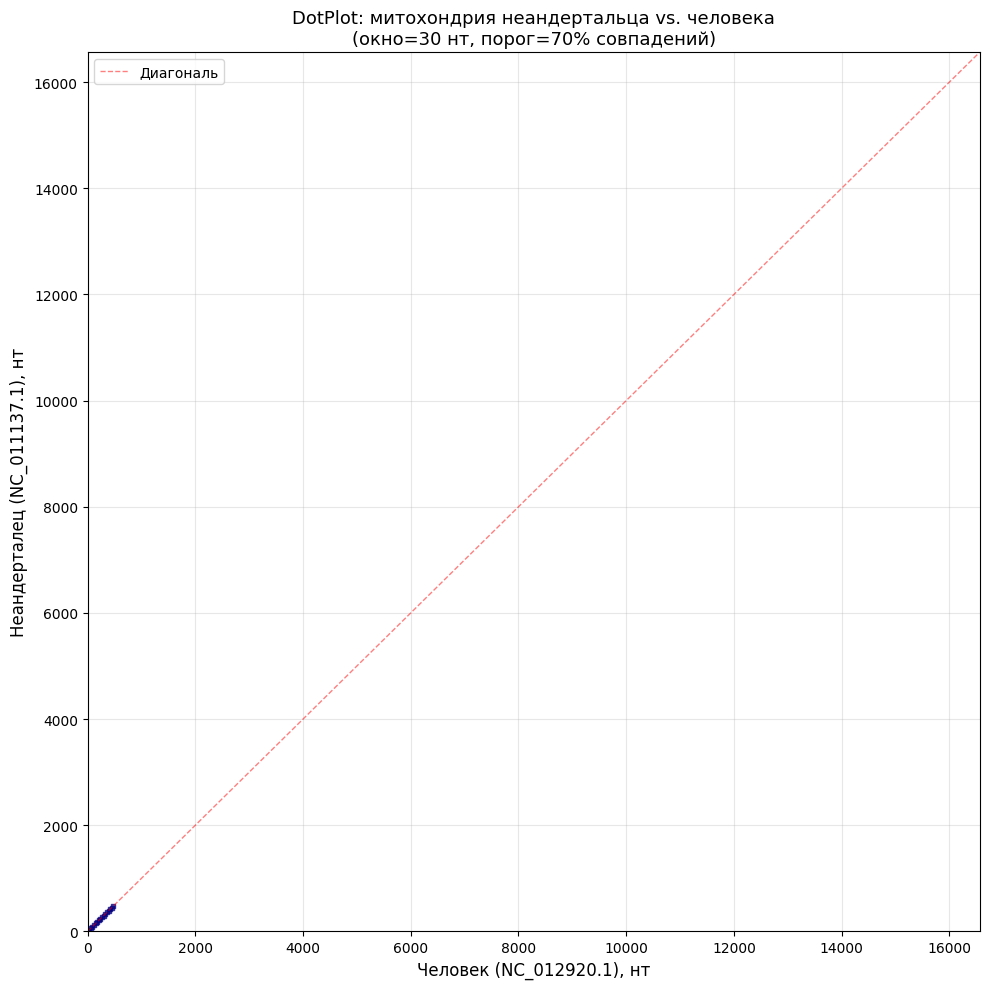

График сохранён: dotplot_mito.png


In [18]:
import matplotlib.pyplot as plt

def read_fasta(filepath):
    """Читает FASTA файл"""
    sequence_lines = []
    with open(filepath, 'r') as f:
        for line in f:
            line = line.strip()
            if line and not line.startswith('>'):
                sequence_lines.append(line.upper())
    return ''.join(sequence_lines)

def dotplot(seq1, seq2, window=30, threshold=70, step=None):
    """DotPlot с настраиваемыми параметрами"""
    if step is None:
        step = window  # можно уменьшить для большей детализации

    n1, n2 = len(seq1), len(seq2)
    dots_x, dots_y = [], []

    for i in range(0, n1 - window, step):
        for j in range(0, n2 - window, step):
            matches = sum(1 for k in range(window) if seq1[i+k] == seq2[j+k])
            if matches >= threshold * window / 100:
                dots_x.append(j)
                dots_y.append(i)

    return dots_x, dots_y

seq_nean = read_fasta("sequence-2.fasta")   # неандерталец
seq_human = read_fasta("sequence.fasta")    # современный человек

print(f"Неандерталец: {len(seq_nean)} нт")
print(f"Человек: {len(seq_human)} нт")

print("\nСтроим DotPlot (window=30, threshold=70%)...")
dx, dy = dotplot(seq_nean, seq_human, window=30, threshold=70, step=30)

print(f"Найдено точек: {len(dx)}")

fig, ax = plt.subplots(figsize=(10, 10))
ax.scatter(dx, dy, s=10, c='navy', alpha=0.7, marker='s')

max_len = min(len(seq_human), len(seq_nean))
ax.plot([0, max_len], [0, max_len], 'r--', alpha=0.5, linewidth=1, label='Диагональ')

ax.set_xlabel("Человек (NC_012920.1), нт", fontsize=12)
ax.set_ylabel("Неандерталец (NC_011137.1), нт", fontsize=12)
ax.set_title("DotPlot: митохондрия неандертальца vs. человека\n"
             "(окно=30 нт, порог=70% совпадений)", fontsize=13)
ax.set_xlim(0, len(seq_human))
ax.set_ylim(0, len(seq_nean))
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("dotplot_mito.png", dpi=150)
plt.show()
print("График сохранён: dotplot_mito.png")

### Анализ DotPlot

На полученном точечном графике видна **практически непрерывная диагональная линия**, проходящая от угла. Это означает:

1. **Крупных структурных перестроек нет**: митохондриальные геномы неандертальца и современного человека синтенны — гены расположены в одном и том же порядке и на тех же цепях.
2. **Инверсий и крупных транслокаций не наблюдается**: отсутствие перпендикулярных или обратных диагональных линий говорит о сохранении ориентации всех блоков.